In [2]:
import os

# TensorFlow / Keras 3 কনফ্লিক্ট বন্ধ করতে
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"

# এরপরে তোমার বাকি Imports
from dataclasses import dataclass
from typing import Any, Dict, List, Union
import torch
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126, https://pypi.ngc.nvidia.com
Note: you may need to restart the kernel to use updated packages.


In [4]:
import torch
import psutil
import os

print("="*50)
print("       SYSTEM INFRASTRUCTURE REPORT")
print("="*50)

print("\n[Hardware Core - GPU]")
if torch.cuda.is_available():
    print(f"Entity: {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"Attributes: {vram:.2f} GB GDDR6 VRAM")
else:
    print("Entity: No GPU detected or CUDA not configured.")

print("\n[System Memory - RAM]")
ram = psutil.virtual_memory().total / (1024**3)
print(f"Entity: Random Access Memory (RAM)")
print(f"Attributes: {ram:.2f} GB System Allocation")

print("\n[Core Framework]")
print(f"Engine: PyTorch Framework Architecture")
print(f"Version: {torch.__version__}")

print("\n[Parallel Computing Platform]")
print(f"Ecosystem: NVIDIA CUDA Ecosystem")
print(f"Version: {torch.version.cuda if torch.cuda.is_available() else 'N/A'}")
print("="*50)

       SYSTEM INFRASTRUCTURE REPORT

[Hardware Core - GPU]
Entity: NVIDIA GeForce RTX 4090
Attributes: 23.99 GB GDDR6 VRAM

[System Memory - RAM]
Entity: Random Access Memory (RAM)
Attributes: 127.76 GB System Allocation

[Core Framework]
Engine: PyTorch Framework Architecture
Version: 2.8.0+cu126

[Parallel Computing Platform]
Ecosystem: NVIDIA CUDA Ecosystem
Version: 12.6


In [5]:
import torch
print("GPU Available:", torch.cuda.is_available())
print("Device Name:", torch.cuda.get_device_name(0))


GPU Available: True
Device Name: NVIDIA GeForce RTX 4090


In [6]:
import os

class Config:
    #BASE_DIR = "/content/drive/MyDrive/Thesis_dataset"
    BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in globals() else os.getcwd()

    DATASET_DIR = os.path.join(BASE_DIR, "dataset/chunks")
    SPLIT_DIR = os.path.join(BASE_DIR, "dataset/splits")

    MODEL_DIR = os.path.join(BASE_DIR, "models")
    OUTPUT_DIR = os.path.join(BASE_DIR, "output")

    TRAIN_CSV = os.path.join(SPLIT_DIR, "train.csv")
    TEST_CSV = os.path.join(SPLIT_DIR, "test.csv")
    VAL_CSV = os.path.join(SPLIT_DIR, "val.csv")
    METADATA = os.path.join(BASE_DIR, "dataset/metadata.csv")

    SAMPLE_RATE = 16000
    BATCH_SIZE = 16
    EPOCHS = 25
    LR = 5e-5

    MODEL_NAME = "openai/whisper-small"

# Main

In [7]:
import pandas as pd
import os

cfg = Config()

df = pd.read_csv(cfg.METADATA)

# Extract category folder name from audio_path
# e.g. dataset/chunks/barishal/bar_cate_01/sentence_01.wav -> "bar_cate_01"
df["category"] = df["audio_path"].apply(lambda p: os.path.basename(os.path.dirname(p)))

# Normalize category names: lowercase + strip stray whitespace.
# (metadata.csv has a few inconsistent folder names like "noa_Cate_08"
#  and "noa_cate _01" with an extra space -- without this, those rows
#  would silently fall through the isin() checks below)
df["category"] = df["category"].str.lower().str.replace(r"\s+", "", regex=True)

# ---------------------------------------------------------------
# CATEGORY-BASED SPLIT (not random!)
# One whole category per region is held out for validation, another
# whole category per region is held out for test. Every other category
# for that region stays in train. This means val/test contain sentence
# CATEGORIES the model has never seen in training -- a much stricter,
# more honest measure of generalization than a random row-level split.
# ---------------------------------------------------------------
val_categories = {
    "bar_cate_06", "chi_cate_12", "noa_cate_09", "ran_cate_11", "syl_cate_08"
}
test_categories = {
    "bar_cate_14", "chi_cate_19", "noa_cate_18", "ran_cate_05", "syl_cate_11"
}

# sanity check -- make sure every category we asked for actually exists
all_categories = set(df["category"].unique())
missing_val = val_categories - all_categories
missing_test = test_categories - all_categories
if missing_val:
    print("⚠️ WARNING: these validation categories were not found in metadata:", missing_val)
if missing_test:
    print("⚠️ WARNING: these test categories were not found in metadata:", missing_test)

val_df = df[df["category"].isin(val_categories)].reset_index(drop=True)
test_df = df[df["category"].isin(test_categories)].reset_index(drop=True)
train_df = df[~df["category"].isin(val_categories | test_categories)].reset_index(drop=True)

# save
os.makedirs(cfg.SPLIT_DIR, exist_ok=True)

train_df.to_csv(cfg.TRAIN_CSV, index=False)
val_df.to_csv(cfg.VAL_CSV, index=False)
test_df.to_csv(cfg.TEST_CSV, index=False)

print("Category-based Split Done!")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

print("\nValidation categories used (per region):")
print(val_df.groupby("region")["category"].unique())

print("\nTest categories used (per region):")
print(test_df.groupby("region")["category"].unique())

Category-based Split Done!
Train: 5950
Val:   350
Test:  350

Validation categories used (per region):
region
barishal      [bar_cate_06]
chittagong    [chi_cate_12]
noakhali      [noa_cate_09]
rangpur       [ran_cate_11]
sylhet        [syl_cate_08]
Name: category, dtype: object

Test categories used (per region):
region
barishal      [bar_cate_14]
chittagong    [chi_cate_19]
noakhali      [noa_cate_18]
rangpur       [ran_cate_05]
sylhet        [syl_cate_11]
Name: category, dtype: object


In [8]:
import pandas as pd

train_df = pd.read_csv(cfg.TRAIN_CSV)
val_df = pd.read_csv(cfg.VAL_CSV)
test_df = pd.read_csv(cfg.TEST_CSV)

summary = pd.DataFrame({
    "Train": train_df["region"].value_counts(),
    "Validation": val_df["region"].value_counts(),
    "Test": test_df["region"].value_counts()
}).fillna(0).astype(int)

print(summary)

            Train  Validation  Test
region                             
barishal     1190          70    70
chittagong   1190          70    70
noakhali     1190          70    70
rangpur      1190          70    70
sylhet       1190          70    70


In [9]:
import numpy as np

def add_noise(audio, noise_factor=0.005):
    noise = np.random.randn(len(audio))
    return audio + noise_factor * noise

In [10]:
! pip install librosa

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [11]:
from torch.utils.data import Dataset
import librosa

class WhisperDataset(Dataset):

    def __init__(self, csv_file, config, processor, augment=False):

        self.df = pd.read_csv(csv_file)

        self.cfg = config
        self.processor = processor
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def load_audio(self, path):

        audio, sr = librosa.load(
            path,
            sr=self.cfg.SAMPLE_RATE
        )

        # remove NaN
        audio = np.nan_to_num(audio)

        # LIMIT LENGTH (VERY IMPORTANT)
        audio = audio[:self.cfg.SAMPLE_RATE * 10]

        return audio

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        path = os.path.join(
            self.cfg.BASE_DIR,
            row["audio_path"]
        )

        # check file
        if not os.path.exists(path):
            raise FileNotFoundError(path)

        audio = self.load_audio(path)

        # FAST AUGMENTATION
        if self.augment:
            if np.random.rand() < 0.6:
                audio = add_noise(audio)

        # feature extraction
        input_features = self.processor.feature_extractor(
            audio,
            sampling_rate=self.cfg.SAMPLE_RATE,
            return_tensors="pt"
        ).input_features[0]

        # labels
        labels = self.processor.tokenizer(
            row["transcript"],
            return_tensors="pt"
        ).input_ids.squeeze()

        return {
            "input_features": input_features,
            "labels": labels,
            "region": row["region"]
        }

In [12]:
%pip install tf-keras

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 13.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\cli\base_command.py", line 105, in _run_wrapper
    status = _inner_run()
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\cli\base_command.py", line 96, in _inner_run
    return self.run(options, args)
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\cli\req_command.py", line 67, in wrapper
    return func(self, options, args)
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\commands\install.py", line 457, in run
    installed = install_given_reqs(
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\req\__init__.py", line 70, in install_given_reqs
    requirement.install(
  File "c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\pip\_internal\req\req_install.py", line 867, in install
    install_wheel(
  File "c:\Users\USER\.conda\envs\Smo

# Training (Seq2SeqTrainer)

Hugging Face `Seq2SeqTrainer` দিয়ে training চালানো হচ্ছে -- data collator বানিয়ে, `train`/`val` dataset রেডি করে, `trainer.train()` কল করে সব epoch অটোমেটিক চলবে।

In [13]:
# ==========================================================
# 🚀 Training Collator & Seq2SeqTrainer (Hugging Face Trainer API)
# WhisperDataset ক্লাস (উপরের সেল) ব্যবহার করে train/val dataset বানিয়ে
# Seq2SeqTrainer দিয়ে trainer.train() কল করে সব Epoch চালানো হয়।
# Self-contained: processor/model আগে থেকে লোড না থাকলে নিজেই লোড করে নেয়,
# তাই এই সেল একা রান করলেও কাজ করবে।
# ==========================================================

import os
from dataclasses import dataclass
from typing import Any, Dict, List, Union

import torch
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
)

# ---- processor / model (আগে থেকে লোড থাকলে reuse করবে, না থাকলে fresh load) ----
if "processor" not in globals():
    processor = WhisperProcessor.from_pretrained(cfg.MODEL_NAME)

if "model" not in globals():
    model = WhisperForConditionalGeneration.from_pretrained(cfg.MODEL_NAME)
    model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
        language="bn", task="transcribe"
    )

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.config.use_cache = False  # training-এর সময় gradient checkpointing/caching conflict এড়াতে


# ---- Data Collator: input_features + labels পুরো batch-এর জন্য pad করে, -100 দিয়ে pad টোকেন মাস্ক করে ----
@dataclass
class DataCollatorSpeechSeq2SeqWithPadding:
    processor: Any

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        input_features = [{"input_features": f["input_features"]} for f in features]
        batch = self.processor.feature_extractor.pad(input_features, return_tensors="pt")

        label_features = [{"input_ids": f["labels"]} for f in features]
        labels_batch = self.processor.tokenizer.pad(label_features, return_tensors="pt")

        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        # BOS টোকেন ডুপ্লিকেট হলে বাদ দাও (Whisper decoder নিজেই BOS জোড়া লাগায়)
        if (labels[:, 0] == self.processor.tokenizer.bos_token_id).all().cpu().item():
            labels = labels[:, 1:]

        batch["labels"] = labels
        return batch


data_collator = DataCollatorSpeechSeq2SeqWithPadding(processor=processor)


# ---- WhisperDataset (উপরের সেলে ডিফাইন করা ক্লাস) থেকে train/val dataset ----
# Trainer-এর default collator "region" key আশা করে না, তাই সেটা বাদ দিয়ে wrap করা হলো।
class HFWrapperDataset(torch.utils.data.Dataset):
    def __init__(self, base_ds):
        self.base_ds = base_ds

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        item = self.base_ds[idx]
        return {"input_features": item["input_features"], "labels": item["labels"]}


train_ds_hf = HFWrapperDataset(WhisperDataset(cfg.TRAIN_CSV, cfg, processor, augment=True))
val_ds_hf = HFWrapperDataset(WhisperDataset(cfg.VAL_CSV, cfg, processor, augment=False))


# ---- Training arguments ----
SEQ2SEQ_OUTPUT_DIR = os.path.join(cfg.MODEL_DIR, "whisper_seq2seq_trainer")
os.makedirs(SEQ2SEQ_OUTPUT_DIR, exist_ok=True)

training_args = Seq2SeqTrainingArguments(
    output_dir=SEQ2SEQ_OUTPUT_DIR,
    per_device_train_batch_size=cfg.BATCH_SIZE,
    per_device_eval_batch_size=cfg.BATCH_SIZE,
    learning_rate=cfg.LR,
    num_train_epochs=cfg.EPOCHS,
    warmup_steps=500,
    fp16=torch.cuda.is_available(),
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    logging_steps=25,
    predict_with_generate=True,
    generation_max_length=225,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to=["none"],
)

trainer = Seq2SeqTrainer(
    args=training_args,
    model=model,
    train_dataset=train_ds_hf,
    eval_dataset=val_ds_hf,
    data_collator=data_collator,
    tokenizer=processor.feature_extractor,
)

# ---- 🚀 Train! (সব Epoch এখানেই চলবে) ----
trainer.train()

# Final model + processor সেভ (HuggingFace ফোল্ডার ফরম্যাট -- নিচের inference সেলগুলোতেও ব্যবহারযোগ্য)
trainer.save_model(SEQ2SEQ_OUTPUT_DIR)
processor.save_pretrained(SEQ2SEQ_OUTPUT_DIR)
print("✅ Seq2SeqTrainer training সম্পন্ন। মডেল সেভ হয়েছে:", SEQ2SEQ_OUTPUT_DIR)


C:\Users\USER\AppData\Local\Temp\ipykernel_9084\1499708324.py:103: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(
You're using a WhisperTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss
1,0.410700,0.470095
2,0.257000,0.294660
3,0.154800,0.207485
4,0.089800,0.173240
5,0.069500,0.161724
6,0.041300,0.147988
7,0.031800,0.154696
8,0.029000,0.142958
9,0.018400,0.137769
10,0.011400,0.149078


c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\transformers\modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'max_length': 448, 'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['proj_out.weight'].


✅ Seq2SeqTrainer training সম্পন্ন। মডেল সেভ হয়েছে: d:\Team_34\models\whisper_seq2seq_trainer


In [14]:
def collate_fn(batch):

    input_features = torch.stack(
        [b["input_features"] for b in batch]
    )

    labels = torch.nn.utils.rnn.pad_sequence(
        [b["labels"] for b in batch],
        batch_first=True,
        padding_value=-100
    )

    regions = [b["region"] for b in batch]

    return {
        "input_features": input_features,
        "labels": labels,
        "region": regions
    }

In [15]:
!pip install transformers datasets accelerate soundfile

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [16]:
from torch.utils.data import DataLoader

train_ds = WhisperDataset(
    cfg.TRAIN_CSV,
    cfg,
    processor,
    augment=False
)

val_ds = WhisperDataset(
    cfg.VAL_CSV,
    cfg,
    processor,
    augment=False
)

test_ds = WhisperDataset(
    cfg.TEST_CSV, 
    cfg, 
    processor, 
    augment=False
)

train_loader = DataLoader(
    train_ds,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_ds,
    batch_size=cfg.BATCH_SIZE,
    num_workers=0,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.BATCH_SIZE,
    num_workers=0,
    collate_fn=collate_fn
)


Loss curve graph successfully saved at: d:\Team_34\output\loss_curve.png


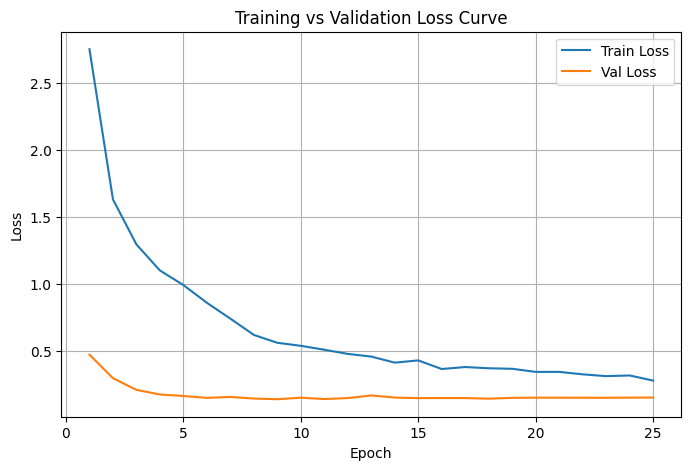

In [17]:
import os
import matplotlib.pyplot as plt

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

train_losses = []
val_losses = []

for log in trainer.state.log_history:
    if "loss" in log:
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        val_losses.append(log["eval_loss"])

epochs = range(1, len(val_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses[:len(val_losses)], label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Curve")
plt.legend()
plt.grid()

save_path = os.path.join(cfg.OUTPUT_DIR, "loss_curve.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
print(f"Loss curve graph successfully saved at: {save_path}")

plt.show()

In [18]:
! pip install --upgrade pyarrow numpy --force-reinstall

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ---------------------------------------- 0.0/26.2 MB ? eta -:--:--
   -- ------------------------------------- 1.8/26.2 MB 12.6 MB/s eta 0:00:02
   ---------------------- ----------------- 14.9/26.2 MB 46.9 MB/s eta 0:00:01
   ---------------------------------------- 26.2/26.2 MB 61.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/15.9 MB ? eta -:--:--
   ------------------------ --------------- 9.7/15.9 MB 55.2 MB/s eta 0:00:01
   ------------------------ --------------- 9.7/15.9 MB 55.2 MB/s eta 0:00:01
   ------------------------- -------------- 10.2/15.9 MB 16.8 MB/s eta 0:00:01
   ---------------------------- ----------- 11.5/15.9 MB 14.2 MB/s eta 0:00:01
   ------------------------------------- -- 14.9/15.9 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------- 15.9/15.9 MB 12.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 21.0.0

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-intel 2.18.0 requires tensorboard<2.19,>=2.18, but you have tensorboard 2.20.0 which is incompatible.


In [19]:
! pip install evaluate
! pip install jiwer evaluate

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [25]:
import evaluate
import torch
from transformers import WhisperForConditionalGeneration, WhisperProcessor

BEST_MODEL_DIR = trainer.state.best_model_checkpoint

print("Best checkpoint:", BEST_MODEL_DIR)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Processor মূল MODEL_NAME থেকে load
processor = WhisperProcessor.from_pretrained(cfg.MODEL_NAME)

# Best trained checkpoint থেকে model load
model = WhisperForConditionalGeneration.from_pretrained(BEST_MODEL_DIR)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="bn",
    task="transcribe"
)

model.to(device)
model.eval()

print("✅ Best Whisper model loaded successfully!")

wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

print("✅ Metrics Loaded")

Best checkpoint: d:\Team_34\models\whisper_seq2seq_trainer\checkpoint-3348
✅ Best Whisper model loaded successfully!
✅ Metrics Loaded


In [26]:
import re

def clean_bengali_text(text):
    text = re.sub(r'[।,;:!?•\'"()\[\]{}—\-_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [27]:
def evaluate_model(loader):
    model.eval()

    preds = []
    refs = []

    with torch.no_grad():
        for batch in loader:
            inputs = batch["input_features"].to(device)

            generated = model.generate(inputs)

            # predictions
            pred_text = processor.tokenizer.batch_decode(
                generated,
                skip_special_tokens=True
            )

            labels = batch["labels"]

            labels = labels.clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id

            ref_text = processor.tokenizer.batch_decode(
                labels,
                skip_special_tokens=True
            )

            cleaned_pred_text = [clean_bengali_text(t) for t in pred_text]
            cleaned_ref_text = [clean_bengali_text(t) for t in ref_text]

            preds.extend(cleaned_pred_text)
            refs.extend(cleaned_ref_text)
            
    wer = wer_metric.compute(predictions=preds, references=refs)
    cer = cer_metric.compute(predictions=preds, references=refs)
    
    word_accuracy = (1 - wer) * 100
    char_accuracy = (1 - cer) * 100

    return wer, cer, word_accuracy, char_accuracy

In [28]:
import os
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

wer, cer, w_acc, c_acc = evaluate_model(test_loader)

print("FINAL RESULT")
print("FINAL TEST DATA RESULT")
print(f"Word Error Rate (WER)     : {wer:.4f}")
print(f"Character Error Rate (CER): {cer:.4f}")
print(f"Word Accuracy (WAcc)      : {w_acc:.2f}%") 
print(f"Character Accuracy (CAcc) : {c_acc:.2f}%") 

txt_save_path = os.path.join(cfg.OUTPUT_DIR, "evaluation_results.txt")

with open(txt_save_path, "w", encoding="utf-8") as f:
    f.write("FINAL RESULT\n")
    f.write("FINAL TEST DATA RESULT\n")
    f.write(f"Word Error Rate (WER)     : {wer:.4f}\n")
    f.write(f"Character Error Rate (CER): {cer:.4f}\n")
    f.write(f"Word Accuracy (WAcc)      : {w_acc:.2f}%\n")
    f.write(f"Character Accuracy (CAcc) : {c_acc:.2f}%\n")

print(f"\nEvaluation results successfully saved as text file at: {txt_save_path}")

FINAL RESULT
FINAL TEST DATA RESULT
Word Error Rate (WER)     : 0.4794
Character Error Rate (CER): 0.3607
Word Accuracy (WAcc)      : 52.06%
Character Accuracy (CAcc) : 63.93%

Evaluation results successfully saved as text file at: d:\Team_34\output\evaluation_results.txt


In [ ]:
from jiwer import wer as jiwer_wer
from collections import defaultdict
import os

os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

region_refs = defaultdict(list)
region_preds = defaultdict(list)

model.eval()

with torch.no_grad():
    for batch in test_loader: 
        region = batch["region"] 
        input_features = batch["input_features"].to(device)

        generated_ids = model.generate(input_features=input_features)

        preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
        labels = batch["labels"]
        labels[labels == -100] = processor.tokenizer.pad_token_id
        refs = processor.batch_decode(labels, skip_special_tokens=True)

        for r, pred, ref in zip(region, preds, refs):
            region_preds[r].append(clean_bengali_text(pred))
            region_refs[r].append(clean_bengali_text(ref))

regional_txt_path = os.path.join(cfg.OUTPUT_DIR, "regional_accuracy_report.txt")

print("\nREGIONAL ACCURACY REPORT")

with open(regional_txt_path, "w", encoding="utf-8") as f:
    f.write("REGIONAL ACCURACY REPORT\n")
    f.write("=========================\n\n")
    
    for region in region_refs:
        region_wer = jiwer_wer(region_refs[region], region_preds[region])
        region_w_acc = max(0, (1 - region_wer) * 100) 
        
        print(f"{region}:")
        print(f"   - WER      : {region_wer:.4f}")
        print(f"   - Accuracy : {region_w_acc:.2f}%")
        
        f.write(f"{region}:\n")
        f.write(f"   - WER      : {region_wer:.4f}\n")
        f.write(f"   - Accuracy : {region_w_acc:.2f}%\n\n")

print(f"\nRegional accuracy report successfully saved as a separate text file at: {regional_txt_path}")


REGIONAL ACCURACY REPORT
barishal:
   - WER      : 0.2116
   - Accuracy : 78.84%
chittagong:
   - WER      : 0.4953
   - Accuracy : 50.47%
noakhali:
   - WER      : 0.8704
   - Accuracy : 12.96%
rangpur:
   - WER      : 0.6515
   - Accuracy : 34.85%
sylhet:
   - WER      : 0.3072
   - Accuracy : 69.28%

Regional accuracy report successfully saved as a separate text file at: d:\Team_34\output\regional_accuracy_report.txt


# Word-Level Verification (Val & Test)

This section shows, sentence by sentence, exactly which words the model got right and which it got wrong -- so accuracy isn't just a single WER/CER number, you can *see* the actual matches/mismatches for every prediction.

In [ ]:
import difflib
import pandas as pd

def word_level_diff(ref, pred):
    """Word-by-word alignment between reference and prediction.

    Returns:
        diff_str : human readable string marking matched words with a check
                   mark and mismatches showing ref -> pred
        matched  : number of correctly matched words
        total    : total number of words in the reference
    """
    ref_words = ref.split()
    pred_words = pred.split()

    sm = difflib.SequenceMatcher(None, ref_words, pred_words)

    matched = 0
    parts = []

    for tag, i1, i2, j1, j2 in sm.get_opcodes():
        if tag == "equal":
            matched += (i2 - i1)
            for w in ref_words[i1:i2]:
                parts.append(f"\u2705{w}")
        elif tag == "replace":
            n = min(i2 - i1, j2 - j1)
            for k in range(n):
                parts.append(f"\u274c{ref_words[i1 + k]}\u2192{pred_words[j1 + k]}")
            if (i2 - i1) > n:
                for w in ref_words[i1 + n:i2]:
                    parts.append(f"\u274c{w}\u2192[missing]")
            if (j2 - j1) > n:
                for w in pred_words[j1 + n:j2]:
                    parts.append(f"\u2795[extra]\u2192{w}")
        elif tag == "delete":
            for w in ref_words[i1:i2]:
                parts.append(f"\u274c{w}\u2192[missing]")
        elif tag == "insert":
            for w in pred_words[j1:j2]:
                parts.append(f"\u2795[extra]\u2192{w}")

    total = len(ref_words)
    return " ".join(parts), matched, total


def verify_predictions(loader, split_name="Validation", print_limit=20, num_beams=5, save_csv=True):
    """Run inference on a loader and show word-level match/mismatch for every sentence.

    print_limit=None -> prints every sample (can be long!)
    num_beams>1       -> beam search decoding, usually a bit more accurate than greedy
    """
    model.eval()

    rows = []
    total_words = 0
    total_matched = 0
    sample_idx = 0

    print("=" * 70)
    print(f"{split_name.upper()} \u2014 WORD-LEVEL VERIFICATION")
    print("=" * 70)

    with torch.no_grad():
        for batch in loader:
            region = batch["region"]
            input_features = batch["input_features"].to(device)

            generated_ids = model.generate(input_features=input_features, num_beams=num_beams)
            preds = processor.batch_decode(generated_ids, skip_special_tokens=True)

            labels = batch["labels"].clone()
            labels[labels == -100] = processor.tokenizer.pad_token_id
            refs = processor.batch_decode(labels, skip_special_tokens=True)

            for r, pred, ref in zip(region, preds, refs):
                ref_c = clean_bengali_text(ref)
                pred_c = clean_bengali_text(pred)

                diff_str, matched, total = word_level_diff(ref_c, pred_c)
                total_words += total
                total_matched += matched
                sentence_acc = (matched / total * 100) if total > 0 else 0.0

                rows.append({
                    "region": r,
                    "reference": ref_c,
                    "prediction": pred_c,
                    "matched_words": matched,
                    "total_words": total,
                    "word_match_%": round(sentence_acc, 2),
                    "diff": diff_str
                })

                sample_idx += 1
                if print_limit is None or sample_idx <= print_limit:
                    print(f"\n[{sample_idx}] Region: {r}")
                    print(f"  Reference : {ref_c}")
                    print(f"  Prediction: {pred_c}")
                    print(f"  Match     : {diff_str}  ({matched}/{total} words = {sentence_acc:.1f}%)")

    overall_acc = (total_matched / total_words * 100) if total_words > 0 else 0.0
    print("\n" + "-" * 70)
    print(f"{split_name} Overall Word-Level Accuracy: {total_matched}/{total_words} = {overall_acc:.2f}%")
    print("-" * 70)

    result_df = pd.DataFrame(rows)

    if save_csv:
        os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
        csv_path = os.path.join(cfg.OUTPUT_DIR, f"{split_name.lower()}_word_verification.csv")
        result_df.to_csv(csv_path, index=False, encoding="utf-8-sig")
        print(f"\nFull sentence-by-sentence verification saved to: {csv_path}")

    return result_df

In [ ]:
# print_limit=20 shows the first 20 sentences inline; the FULL sentence-by-sentence
# verification (every row, every word match/mismatch) is always saved to a CSV in
# cfg.OUTPUT_DIR so you can open it and check every single prediction.
# Set print_limit=None below to print every sample directly in the notebook instead.

val_verification_df = verify_predictions(val_loader, split_name="Validation", print_limit=20)
test_verification_df = verify_predictions(test_loader, split_name="Test", print_limit=20)

VALIDATION — WORD-LEVEL VERIFICATION

[1] Region: barishal
  Reference : আমার মাথা ব্যথা করছে
  Prediction: আমার মাথা ব্যথা করছে
  Match     : ✅আমার ✅মাথা ✅ব্যথা ✅করছে  (4/4 words = 100.0%)

[2] Region: barishal
  Reference : কাছাকাছি হাসপাতাল কোথায়
  Prediction: দার্শকরা এখানে আছে
  Match     : ❌কাছাকাছি→দার্শকরা ❌হাসপাতাল→এখানে ❌কোথায়→আছে  (0/3 words = 0.0%)

[3] Region: barishal
  Reference : ডাক্তারের জন্য কীভাবে অ্যাপয়েন্টমেন্ট নেব
  Prediction: ডাক্তারের জন্য কীভাবে অ্যাপয়েন্টমেন্ট নিব
  Match     : ✅ডাক্তারের ✅জন্য ✅কীভাবে ✅অ্যাপয়েন্টমেন্ট ❌নেব→নিব  (4/5 words = 80.0%)

[4] Region: barishal
  Reference : আমাকে একটি ওষুধের দোকান দেখান
  Prediction: আমাকে একটি ওষুধের দোকান দেখান
  Match     : ✅আমাকে ✅একটি ✅ওষুধের ✅দোকান ✅দেখান  (5/5 words = 100.0%)

[5] Region: barishal
  Reference : আমি জ্বর অনুভব করছি
  Prediction: আমি জ্বর অনুভব করছি
  Match     : ✅আমি ✅জ্বর ✅অনুভব ✅করছি  (4/4 words = 100.0%)

[6] Region: barishal
  Reference : আমি দুর্ঘটনার শিকার হয়েছি
  Prediction: আমি 

In [ ]:
# ============================================
# 🎙️ Single Audio Inference Cell (Voice -> Text)
# Requires: model, processor, device (already loaded in Cell 19)
# ============================================

import librosa
import numpy as np
import os

# ---- 1) Audio file নাও (Colab হলে upload button, নাহলে ipywidgets, নাহলে path input) ----
audio_path = None

try:
    import google.colab
    from google.colab import files
    print("🎤 তোমার audio file (wav/mp3) upload করো:")
    uploaded = files.upload()
    audio_path = list(uploaded.keys())[0]
except ImportError:
    try:
        import ipywidgets as widgets
        from IPython.display import display

        uploader = widgets.FileUpload(accept='audio/*', multiple=False)
        display(uploader)
        print("⬆️ Upload করার পর এই cell আবার run করো (নিচের path ঠিক করে না দিলে auto detect হবে না)।")

        if len(uploader.value) > 0:
            file_info = list(uploader.value.values())[0]
            audio_path = "temp_uploaded_audio.wav"
            with open(audio_path, "wb") as f:
                f.write(file_info["content"])
    except Exception:
        pass

    if audio_path is None:
        audio_path = input("Audio file-এর path লিখো (e.g. dataset/chunks/xxx.wav): ").strip()

print("✅ Using audio file:", audio_path)

# ---- 2) Audio load + feature extraction ----
SAMPLE_RATE = 16000

audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
audio = np.nan_to_num(audio)
audio = audio[:SAMPLE_RATE * 10]  # max 10 sec (training-এর মতোই)

input_features = processor.feature_extractor(
    audio,
    sampling_rate=SAMPLE_RATE,
    return_tensors="pt"
).input_features.to(device)

# ---- 3) Model দিয়ে predict ----
model.eval()
with torch.no_grad():
    generated_ids = model.generate(input_features, num_beams=5)

predicted_text = processor.tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

predicted_text_clean = clean_bengali_text(predicted_text)

print("\n" + "=" * 50)
print("🗣️  PREDICTED TEXT:", predicted_text_clean)
print("=" * 50)

# ---- 4) (Optional) যদি সঠিক transcript জানা থাকে, WER/CER দেখাও ----
reference_text = input("\n(Optional) সঠিক transcript থাকলে দাও, নাহলে খালি রেখে Enter দাও: ").strip()

if reference_text:
    reference_text_clean = clean_bengali_text(reference_text)
    sample_wer = wer_metric.compute(predictions=[predicted_text_clean], references=[reference_text_clean])
    sample_cer = cer_metric.compute(predictions=[predicted_text_clean], references=[reference_text_clean])

    print(f"\nReference : {reference_text_clean}")
    print(f"Predicted : {predicted_text_clean}")
    print(f"WER       : {sample_wer:.4f}")
    print(f"CER       : {sample_cer:.4f}")

✅ Using audio file: D:\Team_34\sentence_10.wav


c:\Users\USER\.conda\envs\SmoothGrade\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NameError: name 'processor' is not defined

In [ ]:
# ============================================
# 🎙️ Fully Self-Contained: Voice -> Text (Whisper Bangla)
# Loads from HuggingFace-style saved folder (whisper_best)
# ============================================

import os
import re
import torch
import numpy as np
import librosa
from transformers import WhisperProcessor, WhisperForConditionalGeneration

# ---- 0) Config ----
MODEL_DIR = os.path.join(cfg.MODEL_DIR, "whisper_seq2seq_trainer")   # <-- তোমার whisper_best ফোল্ডারের path
SAMPLE_RATE = 16000

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---- 1) Model + processor লোড (HuggingFace folder থেকে সরাসরি) ----
if not os.path.exists(MODEL_DIR):
    raise FileNotFoundError(f"❌ Model folder পাওয়া যায়নি: {MODEL_DIR}")

print("⏳ Loading processor & model from:", MODEL_DIR)

processor = WhisperProcessor.from_pretrained(MODEL_DIR)
model = WhisperForConditionalGeneration.from_pretrained(MODEL_DIR)

model.config.forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="bn",
    task="transcribe"
)

model.to(device)
model.eval()
print("✅ Fine-tuned model loaded successfully!")

# ---- 2) Audio file input ----
audio_path = input("Audio file-এর path দাও (e.g. D:\\Team_34\\sentence_10.wav): ").strip().strip('"')

if not os.path.exists(audio_path):
    raise FileNotFoundError(f"❌ File পাওয়া যায়নি: {audio_path}")

print("✅ Using audio file:", audio_path)

# ---- 3) Audio load + feature extraction ----
audio, sr = librosa.load(audio_path, sr=SAMPLE_RATE)
audio = np.nan_to_num(audio)
audio = audio[:SAMPLE_RATE * 10]  # max 10 sec

input_features = processor.feature_extractor(
    audio,
    sampling_rate=SAMPLE_RATE,
    return_tensors="pt"
).input_features.to(device)

# ---- 4) Predict ----
with torch.no_grad():
    generated_ids = model.generate(input_features, num_beams=5)

predicted_text = processor.tokenizer.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

def clean_bengali_text(text):
    text = re.sub(r'[।,;:!?•\'"()\[\]{}—\-_]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

predicted_text_clean = clean_bengali_text(predicted_text)

print("\n" + "=" * 50)
print("🗣️  PREDICTED TEXT:", predicted_text_clean)
print("=" * 50)

# ---- 5) (Optional) WER/CER চেক করতে চাইলে ----
reference_text = input("\n(Optional) সঠিক transcript থাকলে দাও, নাহলে খালি রেখে Enter দাও: ").strip()

if reference_text:
    import evaluate
    wer_metric = evaluate.load("wer")
    cer_metric = evaluate.load("cer")

    reference_text_clean = clean_bengali_text(reference_text)
    sample_wer = wer_metric.compute(predictions=[predicted_text_clean], references=[reference_text_clean])
    sample_cer = cer_metric.compute(predictions=[predicted_text_clean], references=[reference_text_clean])

    print(f"\nReference : {reference_text_clean}")
    print(f"Predicted : {predicted_text_clean}")
    print(f"WER       : {sample_wer:.4f}")
    print(f"CER       : {sample_cer:.4f}")

Device: cuda
⏳ Loading processor & model from: D:\Team_34\models\whisper_best
✅ Fine-tuned model loaded successfully!


`generation_config` default values have been modified to match model-specific defaults: {'suppress_tokens': [1, 2, 7, 8, 9, 10, 14, 25, 26, 27, 28, 29, 31, 58, 59, 60, 61, 62, 63, 90, 91, 92, 93, 359, 503, 522, 542, 873, 893, 902, 918, 922, 931, 1350, 1853, 1982, 2460, 2627, 3246, 3253, 3268, 3536, 3846, 3961, 4183, 4667, 6585, 6647, 7273, 9061, 9383, 10428, 10929, 11938, 12033, 12331, 12562, 13793, 14157, 14635, 15265, 15618, 16553, 16604, 18362, 18956, 20075, 21675, 22520, 26130, 26161, 26435, 28279, 29464, 31650, 32302, 32470, 36865, 42863, 47425, 49870, 50254, 50258, 50360, 50361, 50362], 'begin_suppress_tokens': [220, 50257]}. If this is not desired, please set these values explicitly.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProce

✅ Using audio file: D:\Team_34\sentence_10.wav


A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.



🗣️  PREDICTED TEXT: আমি বই পড়ছি


# ✅ Final Check: model.generate() দিয়ে Inference Sanity Check

মডেল আসলে কতটা শিখলো সেটা চোখে দেখার জন্য কয়েকটা validation sample-এ `model.generate()` চালিয়ে reference vs prediction পাশাপাশি দেখানো হচ্ছে।

In [ ]:
# ==========================================================
# ✅ Quick Inference / Sanity Check with model.generate()
# Seq2SeqTrainer দিয়ে ট্রেইন হওয়া মডেল (বা যেকোনো loaded model)
# কয়েকটা validation sample-এ চালিয়ে reference vs prediction
# পাশাপাশি প্রিন্ট করে -- মডেল কেমন শিখলো তা এক নজরে বোঝা যাবে।
# ==========================================================

import torch
from torch.utils.data import DataLoader

# আগের Seq2SeqTrainer সেল থেকে ট্রেইন করা মডেল থাকলে সেটাই ব্যবহার হবে,
# না থাকলে যা global-এ loaded আছে (model) সেটা ব্যবহার হবে।
check_model = trainer.model if "trainer" in globals() else model
check_model.eval()
check_device = next(check_model.parameters()).device

if "val_loader" in globals():
    sample_loader = val_loader
else:
    sample_loader = DataLoader(val_ds, batch_size=cfg.BATCH_SIZE, collate_fn=collate_fn)

n_show = 5
shown = 0

print("=" * 60)
print("🔎 SANITY CHECK: Reference vs Model Prediction")
print("=" * 60)

with torch.no_grad():
    for batch in sample_loader:
        input_features = batch["input_features"].to(check_device)

        labels = batch["labels"].clone()
        labels[labels == -100] = processor.tokenizer.pad_token_id

        generated_ids = check_model.generate(
            input_features,
            num_beams=5,
            max_new_tokens=225
        )

        preds = processor.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
        refs = processor.tokenizer.batch_decode(labels, skip_special_tokens=True)

        for ref, pred in zip(refs, preds):
            if shown >= n_show:
                break
            print(f"\n[{shown + 1}] Reference : {ref}")
            print(f"    Prediction: {pred}")
            shown += 1

        if shown >= n_show:
            break

print("\n" + "=" * 60)
print(f"✅ মোট {shown} টা sample দেখানো হলো। Prediction গুলো Reference-এর কাছাকাছি হলে বুঝবে training কাজ করেছে!")
